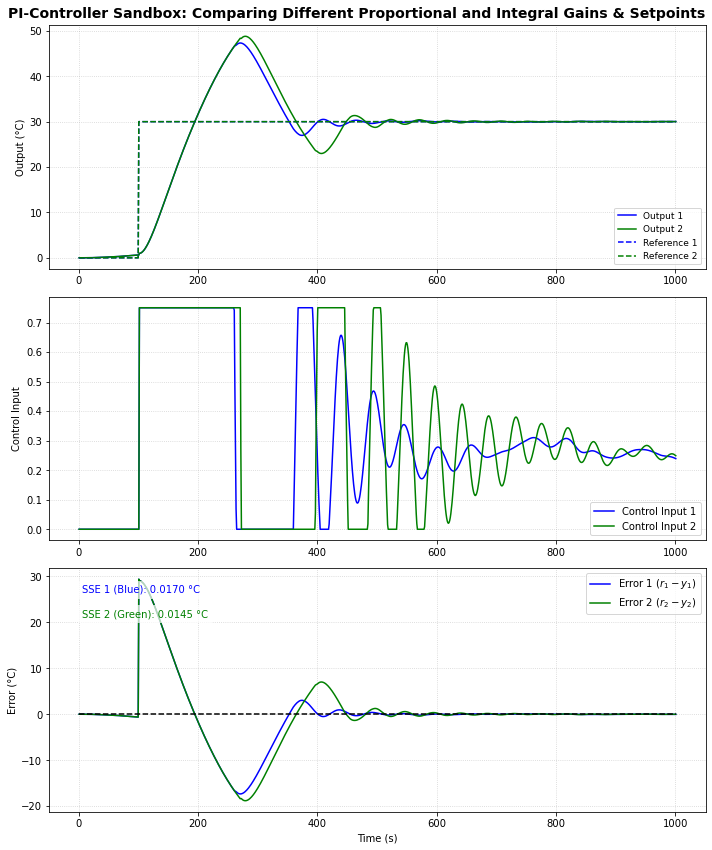

In [ ]:
# PI Control Sandbox (Batch Comparison Mode)

from IPython.display import display, Javascript, clear_output
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import ipywidgets as widgets
import os
import sys

# Define the main function that contains all the logic, setup, and GUI display
def setup_pid_tuner_and_run():
    """
    Encapsulates all data loading, simulation logic, plotting, and GUI setup.
    It returns the GUI widgets and executes the code-hiding script.
    """

    # --- 1. DATA LOADING AND SYSTEM PARAMETERS ---
    data_filename = 'prbs_test_18_Jun_2025_13_50_02.mat'

    # Download the data file if it's not present (Colab environment assumes wget works)
    if not os.path.exists(data_filename):
        print("Downloading data file...")
        os.system('wget -O prbs_test_18_Jun_2025_13_50_02.mat https://raw.githubusercontent.com/AlasMac/TCLab-Python-Resources/main/prbs_test_18_Jun_2025_13_50_02.mat')
        if not os.path.exists(data_filename):
            print("Error: Could not download or find the required .mat data file.")
            return None # Exit function if file is missing

    try:
        data = loadmat(data_filename)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    T = data['T']
    U = data['U']
    y_data_test = T[0, :]
    y_data_test = y_data_test - y_data_test[0]
    # u_data_test is only used for length determination
    u_data_test = U[0, :] 

    # --- Model parameters ---
    # Convert A and B to NumPy arrays immediately to ensure correct type handling
    A = np.array([1, -3.88098254, 5.64726905, -3.6515443, 0.88525793])
    B = np.array([0.4453368, -1.71110786, 2.49838163, -1.64272524, 0.41012833])
    k = 0
    sigma = 1e-5

    # --- System Constants ---
    N = len(u_data_test) # Total simulation time
    u_thresh = 0.75 # Control Input Saturation Limit
    y0 = y_data_test[0] # Initial Temperature

    system_params = {
        'A': A, 'B': B, 'k': k, 'sigma': sigma, 'N': N,
        'u_thresh': u_thresh, 'y0': y0
    }

    # --- 2. CORE SIMULATION AND PLOTTING FUNCTIONS ---

    def ARX_Sim_PID(A, B, k, Kp, Ki, Kd, r_signal, mu, sigma, SIM_TIME, x0, u_thresh):
        """Simulates an ARX model with PID control using a specific reference signal.
        Note: If Kd=0, this functions as a PI controller.
        """
        t = np.arange(1, SIM_TIME + 1)
        rng = np.random.default_rng(seed=100)
        e_noise = rng.normal(mu, sigma, size=len(t))
        
        # A and B are now guaranteed to be np.arrays from the global scope
        na, nb = len(A), len(B)
        L = max(na, nb)

        # Padding logic for mismatched lengths (A and B are already arrays)
        if na > nb: B = np.concatenate([B, np.zeros(na - nb)])
        elif nb > na: A = np.concatenate([A, np.zeros(nb - na)])

        # Increased the size of ut by 1 to prevent IndexError when calculating ut[i+1] 
        # in the last loop iteration (i = SIM_TIME + L - 1).
        ut = np.zeros(len(t) + L + 1)
        y = np.ones(len(t) + L) * x0
        err = np.zeros_like(y)
        integral_err = 0
        alpha = 0.5
        dt = 1.0

        for i in range(L + k, SIM_TIME + L):
            # Check if index is within bounds for reference signal (r_signal is length N)
            r_idx = i - L 
            if r_idx >= SIM_TIME:
                current_r = r_signal[-1]
            else:
                current_r = r_signal[r_idx]
            
            # ARX Model
            y[i] = -np.dot(A[1:], y[i - 1 : i - na : -1]) + np.dot(B, ut[i - k : i - nb - k : -1]) + e_noise[r_idx]
            
            # PI Control (Kd will be 0 for this version)
            err[i] = current_r - y[i]
            integral_err += err[i] * dt
            d_err = err[i] - err[i - 1]
            
            # ut[i+1] calculates the control input to be applied at the next time step (i+1)
            ut[i + 1] = (Kp * err[i] + Ki * integral_err + Kd * (alpha * d_err / dt + (1 - alpha) * d_err))
            ut[i + 1] = np.clip(ut[i + 1], 0, u_thresh)

        # Return results aligned to simulation time
        return y[L : L + SIM_TIME], ut[L : L + SIM_TIME], err[L : L + SIM_TIME], t

    def plot_sandbox(t, y1, u1, e1, t2, y2, u2, e2, r1, r2, Kp1, Kp2, Ki1, Ki2):
        """Plots the results of the two simulations for comparison (PI version)."""
        try: plt.close('all')
        except: pass

        fig, axes = plt.subplots(3, 1, figsize=(10, 12))
        fig.suptitle('PI-Controller Sandbox: Comparing Different Proportional and Integral Gains & Setpoints', fontsize=14, fontweight='bold')

        # Updated labels to include Kp, Ki, and R
        label1 = f'Controller 1 (Blue): $K_p$={Kp1:.3f}, $K_i$={Ki1:.4f}, $R$={r1[-1]:.1f}°C'
        label2 = f'Controller 2 (Green): $K_p$={Kp2:.3f}, $K_i$={Ki2:.4f}, $R$={r2[-1]:.1f}°C'

        # --- Subplot 1: Output ---
        axes[0].plot(t, y1, 'b', label='Output 1')
        axes[0].plot(t2, y2, 'g', label='Output 2')
        # Plot both reference signals
        axes[0].plot(t, r1, 'b--', label='Reference 1') 
        axes[0].plot(t2, r2, 'g--', label='Reference 2')
        axes[0].set_ylabel('Output (°C)')
        axes[0].legend(loc='lower right', fontsize=9)
        axes[0].grid(True, linestyle=':', alpha=0.6)

        # --- Subplot 2: Control Input ---
        axes[1].plot(t, u1, 'b', label='Control Input 1')
        axes[1].plot(t2, u2, 'g', label='Control Input 2')
        axes[1].set_ylabel('Control Input')
        axes[1].legend(loc='lower right')
        axes[1].grid(True, linestyle=':', alpha=0.6)

        # --- Subplot 3: Error Signal ---
        axes[2].plot(t, e1, 'b', label='Error 1 ($r_1-y_1$)')
        axes[2].plot(t2, e2, 'g', label='Error 2 ($r_2-y_2$)')
        axes[2].plot(t, np.zeros_like(t), 'k--') # Zero line for error
        axes[2].set_ylabel('Error (°C)')
        axes[2].set_xlabel('Time (s)')
        axes[2].legend(loc='upper right')
        axes[2].grid(True, linestyle=':', alpha=0.6)

        # Calculate Steady State Error (Average of the last 100 points)
        window = 100
        sse1 = np.mean(np.abs(e1[-window:]))
        sse2 = np.mean(np.abs(e2[-window:]))

        # Display the errors using plt.text
        x_pos = 0.05
        y_pos1 = 0.90
        y_pos2 = 0.80

        axes[2].text(x_pos, y_pos1, 
                     f'SSE 1 (Blue): {sse1:.4f} °C', 
                     transform=axes[2].transAxes, 
                     color='blue', 
                     fontsize=10, 
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        axes[2].text(x_pos, y_pos2, 
                     f'SSE 2 (Green): {sse2:.4f} °C', 
                     transform=axes[2].transAxes, 
                     color='green', 
                     fontsize=10, 
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        plt.tight_layout()
        plt.show()

    # --- 3. INTERACTIVE LOGIC AND GUI SETUP ---

    # Define initial widget values
    Kp1_default, Kp2_default = 0.0, 0.0 # Proportional Gain defaults
    Ki1_default, Ki2_default = 0.0, 0.0 # Integral Gain defaults (new)
    R1_default, R2_default = 30.0, 30.0 # Setpoint defaults

    # Setup Widgets
    style = {'description_width': 'initial', 'handle_color': 'lightblue'}
    Kp1_widget = widgets.FloatText(value=Kp1_default, description='Kp 1:', style=style)
    Ki1_widget = widgets.FloatText(value=Ki1_default, description='Ki 1:', style=style) 
    R1_widget = widgets.FloatText(value=R1_default, description='Ref 1 (°C):', style=style) 

    style2 = {'description_width': 'initial', 'handle_color': 'lightgreen'}
    Kp2_widget = widgets.FloatText(value=Kp2_default, description='Kp 2:', style=style2)
    Ki2_widget = widgets.FloatText(value=Ki2_default, description='Ki 2:', style=style2) 
    R2_widget = widgets.FloatText(value=R2_default, description='Ref 2 (°C):', style=style2) 

    # Define the button callback function
    def run_simulation(b):
        clear_output(wait=True)
        display(input_box) # Re-display the GUI

        # Retrieve P, I, and R values, with explicit float casting for robustness
        Kp1 = float(Kp1_widget.value)
        Kp2 = float(Kp2_widget.value)
        Ki1 = float(Ki1_widget.value)
        Ki2 = float(Ki2_widget.value)
        R1 = float(R1_widget.value)
        R2 = float(R2_widget.value)

        # Fixed Kd to zero for PI control
        Kd1 = 0.0
        Kd2 = 0.0

        try:
            params = system_params
            N = params['N']
            
            # Create dynamic reference arrays based on widget values
            r1 = np.zeros(N, dtype=float)
            r2 = np.zeros(N, dtype=float)
            
            # Apply the step change at t=100s
            r1[100:] = R1
            r2[100:] = R2

            # Run simulations, passing Ki values
            y1, u1, e1, t1 = ARX_Sim_PID(params['A'], params['B'], params['k'], Kp1, Ki1, Kd1, r1, 0, params['sigma'], params['N'], params['y0'], params['u_thresh'])
            y2, u2, e2, t2 = ARX_Sim_PID(params['A'], params['B'], params['k'], Kp2, Ki2, Kd2, r2, 0, params['sigma'], params['N'], params['y0'], params['u_thresh'])

            # Plot results, passing Kp and Ki for plot label
            plot_sandbox(t1, y1, u1, e1, t2, y2, u2, e2, r1, r2, Kp1, Kp2, Ki1, Ki2)
            
        except Exception as e:
            print(f"Error during simulation: {e}")

    # Setup the button
    button = widgets.Button(description="🚀 Run Simulation (Compare)",
                            button_style='success',
                            layout=widgets.Layout(width='auto', height='40px'))
    button.on_click(run_simulation)

    # Layout organization (Kp, Ki, and R widgets are visible)
    ctrl1_label = widgets.Label(value="🔵 Controller 1 (PI)")
    ctrl1_box = widgets.VBox([ctrl1_label, Kp1_widget, Ki1_widget, R1_widget])
    
    ctrl2_label = widgets.Label(value="🟢 Controller 2 (PI)")
    ctrl2_box = widgets.VBox([ctrl2_label, Kp2_widget, Ki2_widget, R2_widget])

    input_box = widgets.HBox([ctrl1_box, widgets.VBox([widgets.Label(value=''), button]) , ctrl2_box],
                              layout=widgets.Layout(justify_content='space-around'))

    return input_box


# --- FINAL FUNCTION CALLS (Minimal code visible to the user) ---

# Run the entire setup function
main_input_box = setup_pid_tuner_and_run()

if main_input_box:
    # 1. Display the GUI
    print("Adjust the proportional (Kp) and integral (Ki) gains, and setpoints below to compare PI control behavior.")
    display(main_input_box)

    # 2. Hide the entire code cell input area using JavaScript
    display(Javascript("""
      var cells = Jupyter.notebook.get_cells();
      var current_cell_index = cells.indexOf(Jupyter.notebook.get_selected_cell());
      var target_cell = cells[current_cell_index];

      if (target_cell) {
        target_cell.collapse_input();
      }
    """))
